In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "ziya07/student-mental-health-and-resilience-dataset"
)

print("Path to dataset files:", path)

100%|██████████| 24.3k/24.3k [00:00<00:00, 25.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ziya07/student-mental-health-and-resilience-dataset/versions/1


In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import os

# Download dataset
path = kagglehub.dataset_download(
    "ziya07/student-mental-health-and-resilience-dataset"
)

# Find CSV file
files = os.listdir(path)
csv_file = [file for file in files if file.endswith(".csv")][0]

# Read dataset
df = pd.read_csv(
    os.path.join(path, csv_file),
    engine="python",
    on_bad_lines="skip"
)

# First 5 Rows
print("First 5 Rows")
print(df.head())

# Shape
print("\nShape")
print(df.shape)

# Data Types
print("\nData Types")
print(df.dtypes)

# Statistics
print("\nStatistics")
print(df.describe())

# Show column names
print("\nColumn Names")
print(df.columns)

Using Colab cache for faster access to the 'student-mental-health-and-resilience-dataset' dataset.
First 5 Rows
   Student_ID  Age  Gender   GPA  Stress_Level  Anxiety_Score  \
0           1   23   Other  2.52             5             20   
1           2   19    Male  2.74             5              3   
2           3   21  Female  3.53             5             11   
3           4   18    Male  2.04             4             15   
4           5   19   Other  2.87             1              2   

   Depression_Score                                  Daily_Reflections  \
0                 6  Onto foreign do environmental anyone every nea...   
1                 7  Party but others visit admit industry country ...   
2                24  Religious sure wait do chance decade according...   
3                14            A task effect entire coach join series.   
4                 4  Knowledge several camera wait week write quali...   

   Sleep_Hours  Steps_Per_Day Mood_Description  Sent

In [3]:
# Numerical columns
num_cols = df.select_dtypes(include="number").columns

print("\nNumerical Columns")
print(num_cols)


# --------------------------------------------------
# FILTERING
# --------------------------------------------------

if len(num_cols) > 0:

    # Filter values greater than the mean
    filtered = df[
        df[num_cols[0]] > df[num_cols[0]].mean()
    ]

    print("\nFiltered Data")
    print(filtered.head())


# --------------------------------------------------
# SORTING
# --------------------------------------------------

if len(num_cols) > 0:

    sorted_df = df.sort_values(
        by=num_cols[0],
        ascending=False
    )

    print("\nSorted Data")
    print(sorted_df.head())


# --------------------------------------------------
# STATISTICAL ANALYSIS
# --------------------------------------------------

for col in num_cols:

    print("\nColumn:", col)

    print("Mean:", df[col].mean())

    print("Median:", df[col].median())

    print("Mode:", df[col].mode()[0])

    print("Standard Deviation:", df[col].std())


# --------------------------------------------------
# GROUPING
# --------------------------------------------------

cat_cols = df.select_dtypes(include="object").columns

print("\nCategorical Columns")
print(cat_cols)

if len(cat_cols) > 0 and len(num_cols) > 0:

    grouped = df.groupby(cat_cols[0])[num_cols].mean()

    print("\nGrouped Data")
    print(grouped)


# --------------------------------------------------
# CORRELATION
# --------------------------------------------------

if len(num_cols) > 1:

    corr = df[num_cols].corr()

    print("\nCorrelation Matrix")
    print(corr)


Numerical Columns
Index(['Student_ID', 'Age', 'GPA', 'Stress_Level', 'Anxiety_Score',
       'Depression_Score', 'Sleep_Hours', 'Steps_Per_Day', 'Sentiment_Score',
       'Mental_Health_Status'],
      dtype='object')

Filtered Data
     Student_ID  Age Gender   GPA  Stress_Level  Anxiety_Score  \
250         251   18   Male  3.64             1             10   
251         252   20   Male  2.54             2              5   
252         253   20   Male  2.51             3              5   
253         254   20   Male  3.84             2              4   
254         255   22  Other  3.64             4              2   

     Depression_Score                                  Daily_Reflections  \
250                 6         Response drop his site here current piece.   
251                 9  Onto ten season natural happy good relate gas ...   
252                 8               Short top again think each task her.   
253                11     Work respond when series cold structure

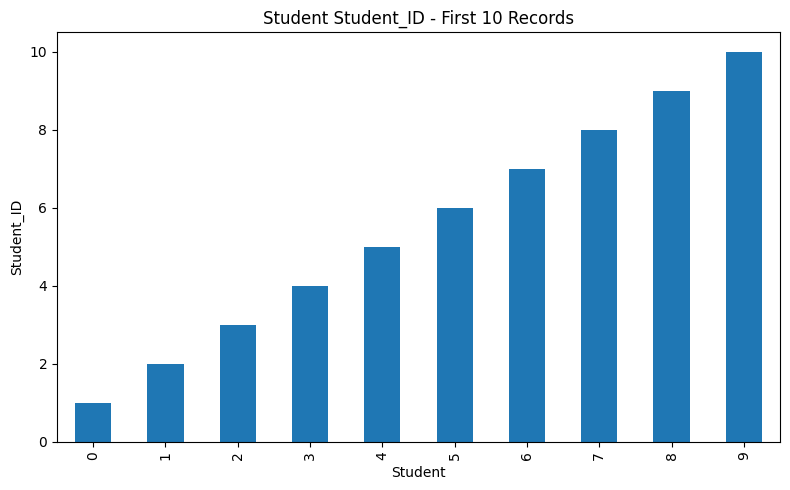

In [4]:
if len(num_cols) > 0:

    plt.figure(figsize=(8,5))

    df[num_cols[0]].head(10).plot(
        kind="bar"
    )

    plt.xlabel("Student")
    plt.ylabel(num_cols[0])

    plt.title(
        "Student " + num_cols[0] + " - First 10 Records"
    )

    plt.tight_layout()
    plt.show()

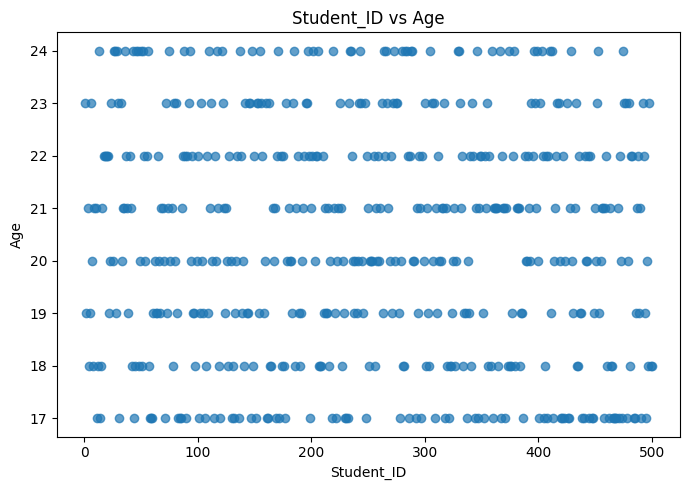

In [5]:
if len(num_cols) >= 2:

    plt.figure(figsize=(7,5))

    plt.scatter(
        df[num_cols[0]],
        df[num_cols[1]],
        alpha=0.7
    )

    plt.xlabel(num_cols[0])
    plt.ylabel(num_cols[1])

    plt.title(
        num_cols[0] + " vs " + num_cols[1]
    )

    plt.tight_layout()
    plt.show()